In [16]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp

(753, 450)

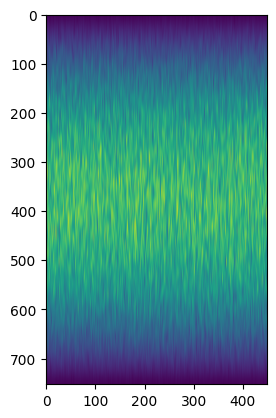

In [30]:
# Definition of the function to simulate CT and dCT

# define average CT
x = np.linspace(0, 752, 753)
mean_CT = -(x-np.mean(x))**2
mean_CT = mean_CT - np.min(mean_CT) 
mean_CT = mean_CT/np.max(mean_CT)
mean_CT = np.expand_dims(mean_CT, axis=1)

# define average dCT
fs = 15 # Hz
L = 30 # seconds
dt = 1/fs*np.ones(L*fs) + np.random.normal(0, 1/fs*0.3, L*fs)
t = np.cumsum(dt)
t = np.expand_dims(t, axis=0)
f_inst = 1 # Hz
mean_dCT = 0.1*(np.sin(2*np.pi*f_inst*t)+1)/2 * mean_CT

CT = mean_CT + mean_dCT
CT = CT + np.random.normal(0, mean_CT*0.8, CT.shape) # add noise
CT = sp.ndimage.gaussian_filter(CT, sigma=[10,0]) # smooth

plt.imshow(CT)


CT.shape

